# IBOVESPA | Previsão de tendência do dia seguinte

Este notebook foi estruturado para ficar **coerente com a proposta da atividade**:

- previsão binária de **alta (1)** ou **baixa/empate (0)** no **dia seguinte**
- uso de **dados diários**
- separação temporal com:
  - **treino**
  - **validação**
  - **teste final = últimos 30 dias**
- seleção do melhor modelo pela **validação**
- uso do **teste final apenas no fim**
- comparação com **baseline**
- análise de métricas, overfitting e limitações

> Regra do target:  
> **Target = 1** quando `Close(t+1) > Close(t)`  
> **Target = 0** caso contrário

## 1. Importação das bibliotecas

In [2]:
# Retirar avisos desnecessários no notebook
import warnings

# Tratamento de texto e padronização de caracteres
import unicodedata

# Manipulação numérica e tabular
import numpy as np
import pandas as pd

# Criação de gráficos
import matplotlib.pyplot as plt

# Padronização das variáveis numéricas
from sklearn.preprocessing import StandardScaler

# Métricas de avaliação dos modelos
from sklearn.metrics import (
    accuracy_score,          # calcula a acurácia
    classification_report,   # mostra precision, recall e f1-score
    confusion_matrix,        # gera a matriz de confusão
    ConfusionMatrixDisplay   # plota a matriz de confusão
)

# Modelos de classificação
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Remove avisos do tipo warning para deixar a saída mais limpa
warnings.filterwarnings("ignore")

# Exibe todas as colunas do DataFrame nas visualizações
pd.set_option("display.max_columns", None)

## 2. Definição dos parâmetros
Definição dos principais parâmetros que serão utilizados ao longo do notebook.


Esses parâmetros ajudam a padronizar a execução e facilitam ajustes futuros sem a necessidade de alterar várias partes do código.


Embora a atividade exija apenas a separação dos últimos 30 dias para teste, incluímos também uma janela de validação. Isso permite comparar os modelos e ajustar parâmetros sem utilizar o conjunto de teste para tomada de decisão, tornando a avaliação final mais confiável.

In [3]:
# Caminho do arquivo CSV
file_path = "../data/raw/Dados Históricos - Ibovespa.csv"

# Quantidade de dias reservados para o teste final
# Conforme exigido na atividade, o teste deve conter os últimos 30 dias
test_size = 30

# Quantidade de dias reservados para validação
# Essa amostra será usada para comparar modelos sem contaminar o teste final
val_size = 30

# Sempre que houver aleatoriedade no treinamento, esse valor ajuda a reproduzir os mesmos resultados
random_state = 42

## 3. Leitura da base

In [6]:
# Lê o arquivo CSV
df_raw = pd.read_csv(file_path)

# Dimensão da base original
print("Dimensão da base bruta:", df_raw.shape)

# Nomes das colunas disponíveis no arquivo
print("Colunas da base:", df_raw.columns.tolist())

df_raw.head()

Dimensão da base bruta: (5000, 7)
Colunas da base: ['Data', 'Último', 'Abertura', 'Máxima', 'Mínima', 'Vol.', 'Var%']


,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%
0,10.03.2026,183.447,180.921,185.324,180.693,"10,08B","1,40%"
1,09.03.2026,180.915,179.367,181.952,177.637,"11,42B","0,86%"
2,06.03.2026,179.365,180.463,181.091,178.556,"9,92B","-0,61%"
3,05.03.2026,180.464,185.365,185.366,179.895,"10,60B","-2,64%"
4,04.03.2026,185.366,183.110,186.306,183.110,"9,11B","1,24%"


## 4. Limpeza e padronização dos nomes das colunas

In [7]:
# Remove acentos e caracteres especiais de um texto
def strip_accents(text):
    return "".join(
        ch for ch in unicodedata.normalize("NFKD", str(text))
        if not unicodedata.combining(ch)
    )

# Padroniza o nome da coluna:
# remove acentos, símbolos, espaços extras e converte para letras minúsculas
def clean_col(col):
    col = strip_accents(col)
    col = col.replace(".", "").replace("%", "").strip().lower()
    return col

# Cria um dicionário que relaciona o nome padronizado ao nome original da coluna
cols_map = {clean_col(c): c for c in df_raw.columns}

cols_map

{'data': 'Data',
 'ultimo': 'Último',
 'abertura': 'Abertura',
 'maxima': 'Máxima',
 'minima': 'Mínima',
 'vol': 'Vol.',
 'var': 'Var%'}

## 5. Mapeamento das colunas para um padrão único

In [8]:
# Dicionário que armazenará a relação entre o nome original da coluna e o nome padronizado que será usado
rename = {}

# Percorre o mapeamento de nomes padronizados gerado no bloco anterior
for clean_name, original_name in cols_map.items():
    
    # Coluna de data
    if "data" in clean_name:
        rename[original_name] = "Date"
    
    # Coluna de fechamento
    elif "ultimo" in clean_name or "fechamento" in clean_name:
        rename[original_name] = "Close"
    
    # Coluna de abertura
    elif "abert" in clean_name:
        rename[original_name] = "Open"
    
    # Coluna de máxima do dia
    elif "max" in clean_name:
        rename[original_name] = "High"
    
    # Coluna de mínima do dia
    elif "min" in clean_name:
        rename[original_name] = "Low"
    
    # Coluna de volume negociado
    elif "vol" in clean_name:
        rename[original_name] = "Volume"
    
    # Coluna de variação percentual diária
    elif "var" in clean_name:
        rename[original_name] = "VarPct"

rename

{'Data': 'Date',
 'Último': 'Close',
 'Abertura': 'Open',
 'Máxima': 'High',
 'Mínima': 'Low',
 'Vol.': 'Volume',
 'Var%': 'VarPct'}

## 6. Tratamento dos formatos e estruturação da base
Após padronizar os nomes das colunas, realizamos o tratamento dos formatos da base para que os dados possam ser utilizados corretamente nas etapas de análise e modelagem.


A base do Investing vem com:
- datas em formato textual
- valores numéricos no padrão brasileiro
- volume com sufixos como `K`, `M` e `B`
- variação percentual com símbolo `%`

In [11]:
# Cria um novo DataFrame já com as colunas renomeadas.
df = df_raw.rename(columns=rename).copy()

# Função para converter números no padrão brasileiro para float
# De: "123.456,78" | Para: 123456.78
def coerce_pt_number(value):
    if pd.isna(value):
        return np.nan
    
    value = str(value).strip().replace(".", "").replace(",", ".")
    
    try:
        return float(value)
    except ValueError:
        return np.nan

# Função para converter o volume negociado
# K = mil | M = milhão | B = bilhão
def parse_pt_volume(value):
    if pd.isna(value):
        return np.nan

    s = str(value).strip()
    multiplier = 1

    if s.endswith(("K", "k")):
        multiplier = 1e3
        s = s[:-1]
    elif s.endswith(("M", "m")):
        multiplier = 1e6
        s = s[:-1]
    elif s.endswith(("B", "b")):
        multiplier = 1e9
        s = s[:-1]

    s = s.replace(".", "").replace(",", ".")
    
    try:
        return float(s) * multiplier
    except ValueError:
        return np.nan

# Converte a coluna de data para datetime
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")

# Converte as colunas de preço para float
for col in ["Open", "High", "Low", "Close"]:
    if col in df.columns:
        df[col] = df[col].apply(coerce_pt_number)

# Converte a coluna de volume para valor numérico
if "Volume" in df.columns:
    df["Volume"] = df["Volume"].apply(parse_pt_volume)

# Converte a coluna de variação percentual para formato decimal
# De: "1,25%" | Para: 0.0125
if "VarPct" in df.columns:
    df["VarPct"] = (
        df["VarPct"]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
    )
    df["VarPct"] = pd.to_numeric(df["VarPct"], errors="coerce") / 100

# Ordena a base cronologicamente e define a data como índice
df = df.sort_values("Date").set_index("Date")

# Verifica os tipos finais das colunas após o tratamento
print("Tipos das colunas após conversão:")
print(df.dtypes)

print("\nValores ausentes por coluna:")
print(df.isna().sum())

df.head()

Tipos das colunas após conversão:
Close     float64
Open      float64
High      float64
Low       float64
Volume    float64
VarPct    float64
dtype: object

Valores ausentes por coluna:
Close     0
Open      0
High      0
Low       0
Volume    1
VarPct    0
dtype: int64


,Close,Open,High,Low,Volume,VarPct
Date,,,,,,
2006-01-02,33507.0,33462.0,33519.0,3286.0,72320000.0,0.0015
2006-01-03,34541.0,33507.0,34563.0,33507.0,148380000.0,0.0309
2006-01-04,35002.0,3454.0,35223.0,3454.0,147130000.0,0.0133
2006-01-05,34936.0,35006.0,35088.0,34681.0,142070000.0,-0.0019
2006-01-06,35475.0,3517.0,35529.0,3494.0,115090000.0,0.0154


## 7. Conferência inicial da base tratada

In [12]:
# Exibe informações gerais da base após o tratamento
print(f"Período da base: {df.index.min().date()} até {df.index.max().date()}")
print(f"Quantidade de linhas: {len(df)}")
print(f"Quantidade de colunas: {df.shape[1]}")

print("\nEstatísticas descritivas das variáveis numéricas:")
df.describe().T

Período da base: 2006-01-02 até 2026-03-10
Quantidade de linhas: 5000
Quantidade de colunas: 6

Estatísticas descritivas das variáveis numéricas:


,count,mean,std,min,25%,50%,75%,max
Close,5000.0,7.115498e+04,3.728512e+04,374.0000,4.997150e+04,6.286850e+04,1.028152e+05,1.912470e+05
Open,5000.0,7.101514e+04,3.744815e+04,389.0000,4.965250e+04,6.291050e+04,1.028662e+05,1.914910e+05
High,5000.0,7.210401e+04,3.724681e+04,385.0000,5.074625e+04,6.369450e+04,1.040855e+05,1.926240e+05
Low,5000.0,7.085513e+04,3.695973e+04,387.0000,4.962700e+04,6.246400e+04,1.021802e+05,1.904190e+05
Volume,4999.0,5.596427e+08,2.259351e+09,112100.0000,2.830000e+06,4.480000e+06,1.107000e+07,2.487000e+10
VarPct,5000.0,4.757200e-04,1.641992e-02,-0.1478,-7.800000e-03,6.000000e-04,9.000000e-03,1.466000e-01


## 8. Exploração inicial dos dados
Visualização inicial da série temporal do fechamento diário do IBOVESPA.

Esse gráfico permite observar:
- a evolução do índice ao longo do tempo
- períodos de alta e baixa
- oscilações mais intensas em determinados intervalos
- possíveis mudanças de comportamento da série

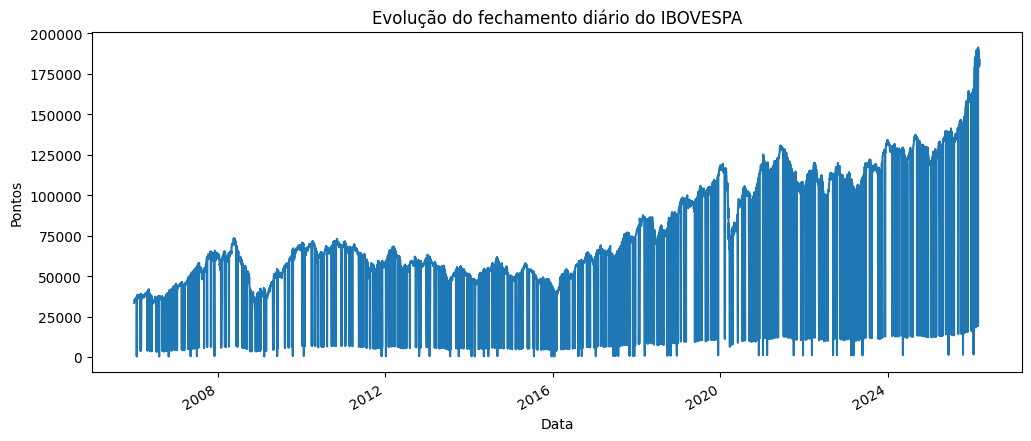

In [ ]:
# Gráfico da série de fechamento diário do IBOVESPA para visualizar a evolução do índice ao longo do tempo
fig, ax = plt.subplots(figsize=(12, 5))

# Plota a série de fechamento
df["Close"].plot(ax=ax)

ax.set_title("Evolução do fechamento diário do IBOVESPA")
ax.set_xlabel("Data")
ax.set_ylabel("Pontos")

plt.show()

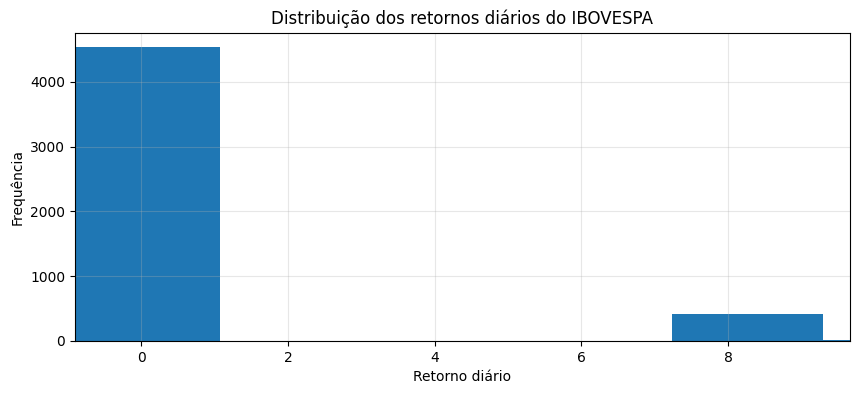

In [26]:
# Distribuição dos retornos diários

# Calcula os retornos diários
df["Return_1d_raw"] = df["Close"].pct_change()

# Remove nulos
retornos = df["Return_1d_raw"].dropna()

# Define limites usando quantis para reduzir impacto de outliers
lim_inf = retornos.quantile(0.01)
lim_sup = retornos.quantile(0.99)

fig, ax = plt.subplots(figsize=(10, 4))
retornos.hist(bins=50, ax=ax)

ax.set_title("Distribuição dos retornos diários do IBOVESPA")
ax.set_xlabel("Retorno diário")
ax.set_ylabel("Frequência")
ax.set_xlim(lim_inf, lim_sup)
ax.grid(alpha=0.3)

plt.show()

## 9. Definição do target
Definimos a variável alvo (`Target`) que será utilizada no problema de classificação.

De acordo com o enunciado da atividade, o objetivo é prever se o fechamento do IBOVESPA no dia seguinte será maior ou menor que o fechamento do dia atual.
- `Target = 1` quando o fechamento de amanhã for maior que o fechamento de hoje
- `Target = 0` quando o fechamento de amanhã for menor ou igual ao fechamento de hoje

Para isso, criamos primeiro a coluna `Next_Close`, que representa o fechamento do próximo dia útil, e em seguida comparamos esse valor com o fechamento atual.

In [27]:
# Cria uma coluna com o fechamento do próximo dia útil
# A função shift(-1) desloca a série uma posição para cima
df["Next_Close"] = df["Close"].shift(-1)

# Define a variável alvo do modelo:
# 1 = fechamento do dia seguinte maior que o fechamento atual
# 0 = fechamento do dia seguinte menor ou igual ao fechamento atual
df["Target"] = (df["Next_Close"] > df["Close"]).astype(int)

# Exibe algumas linhas para conferir visualmente se o target foi construído corretamente
df[["Close", "Next_Close", "Target"]].head(10)

,Close,Next_Close,Target
Date,,,
2006-01-02,33507.0,34541.0,1
2006-01-03,34541.0,35002.0,1
2006-01-04,35002.0,34936.0,0
2006-01-05,34936.0,35475.0,1
2006-01-06,35475.0,35337.0,0
2006-01-09,35337.0,35049.0,0
2006-01-10,35049.0,35952.0,1
2006-01-11,35952.0,35779.0,0
2006-01-12,35779.0,35897.0,1


## 10. Verificação da distribuição das classes
Após definir o target, é importante analisar como as classes estão distribuídas na base.

Essa etapa permite verificar se há equilíbrio entre os dias classificados como alta (`1`) e baixa/estabilidade (`0`).

Entender essa proporção é relevante porque distribuições muito desbalanceadas podem influenciar o treinamento e a avaliação dos modelos. Além disso, essa análise ajuda a interpretar melhor a acurácia obtida, comparando o desempenho do modelo com a frequência natural das classes.

In [28]:
# Monta uma tabela com contagem absoluta e percentual de cada classe
class_summary = pd.DataFrame({
    "Contagem": df["Target"].value_counts(dropna=False).sort_index(),
    "Percentual (%)": (df["Target"].value_counts(normalize=True, dropna=False).sort_index() * 100).round(2)
})

# Exibe o resumo da distribuição do target
print("Distribuição das classes do target:")
display(class_summary)

Distribuição das classes do target:


,Contagem,Percentual (%)
Target,,
0,2412,48.24
1,2588,51.76


## 11. Engenharia de atributos
Nesta etapa, criamos variáveis derivadas do histórico do próprio índice para transformar a série original em uma base mais informativa para o modelo.

Como o objetivo é prever a direção do fechamento do próximo dia, buscamos representar diferentes aspectos do comportamento recente do IBOVESPA, como:
- **retorno**: variações percentuais em diferentes janelas
- **tendência**: médias móveis e distância do preço em relação a essas médias
- **momentum**: intensidade do movimento recente
- **volatilidade**: dispersão dos retornos em janelas móveis
- **indicadores técnicos**: RSI, MACD, Bollinger %B e Estocástico
- **estrutura do candle diário**: amplitude, corpo e posição do fechamento na faixa do dia
- **efeitos de calendário**: dia da semana e mês

Essas variáveis ajudam o modelo a capturar padrões temporais e comportamentos recentes do mercado sem utilizar informação futura.

Todas as features foram construídas apenas com informações disponíveis até o dia atual, evitando vazamento de informação futura para o modelo.

In [29]:
# Retornos em diferentes janelas
# Capturam a variação percentual do fechamento em horizontes curtos
df["Ret_1d"] = df["Close"].pct_change(1)
df["Ret_3d"] = df["Close"].pct_change(3)
df["Ret_5d"] = df["Close"].pct_change(5)
df["Ret_10d"] = df["Close"].pct_change(10)

# Retornos defasados de 1 dia
# Representam o comportamento recente da série em períodos anteriores
for lag in [1, 2, 3, 5, 10]:
    df[f"Ret_1d_lag_{lag}"] = df["Ret_1d"].shift(lag)

# Médias móveis e distância em relação ao preço
# Médias móveis simples
df["SMA_5"] = df["Close"].rolling(5).mean()
df["SMA_10"] = df["Close"].rolling(10).mean()
df["SMA_20"] = df["Close"].rolling(20).mean()

# Médias móveis exponenciais
df["EMA_10"] = df["Close"].ewm(span=10, adjust=False).mean()
df["EMA_20"] = df["Close"].ewm(span=20, adjust=False).mean()

# Distância do fechamento em relação às médias móveis simples
df["Dist_SMA_5"] = df["Close"] / df["SMA_5"] - 1
df["Dist_SMA_10"] = df["Close"] / df["SMA_10"] - 1
df["Dist_SMA_20"] = df["Close"] / df["SMA_20"] - 1

# Momentum
# Mede a força do movimento recente do preço
df["Momentum_3"] = df["Close"] - df["Close"].shift(3)
df["Momentum_7"] = df["Close"] - df["Close"].shift(7)
df["Momentum_14"] = df["Close"] - df["Close"].shift(14)

# Volatilidade
# Mede a dispersão dos retornos em janelas móveis
df["Vol_5"] = df["Ret_1d"].rolling(5).std()
df["Vol_10"] = df["Ret_1d"].rolling(10).std()
df["Vol_20"] = df["Ret_1d"].rolling(20).std()

# RSI (Índice de Força Relativa)
delta = df["Close"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss
df["RSI_14"] = 100 - (100 / (1 + rs))

# MACD
ema_fast = df["Close"].ewm(span=12, adjust=False).mean()
ema_slow = df["Close"].ewm(span=26, adjust=False).mean()
df["MACD"] = ema_fast - ema_slow
df["MACD_signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

# Bollinger %B
bb_mid = df["Close"].rolling(20).mean()
bb_std = df["Close"].rolling(20).std()
bb_up = bb_mid + 2 * bb_std
bb_low = bb_mid - 2 * bb_std
df["BB_pctB"] = (df["Close"] - bb_low) / (bb_up - bb_low).replace(0, np.nan) # Pode haver divisão por zero em alguns casos raros


# Oscilador Estocástico
lowest_low = df["Low"].rolling(14).min()
highest_high = df["High"].rolling(14).max()
df["StochK"] = 100 * (df["Close"] - lowest_low) / (highest_high - lowest_low)

# Estrutura do candle e faixa diária
df["Daily_Range"] = df["High"] - df["Low"]
df["Body"] = df["Close"] - df["Open"]
df["Amplitude_pct"] = (df["High"] - df["Low"]) / df["Close"]
df["Close_pos_in_range"] = (df["Close"] - df["Low"]) / (df["High"] - df["Low"]).replace(0, np.nan) # Pode haver divisão por zero em alguns casos raros

# Tendência e efeitos de calendário
df["Trend_SMA_5_20"] = (df["SMA_5"] > df["SMA_20"]).astype(int)
df["Day_of_Week"] = df.index.dayofweek
df["Month"] = df.index.month

print(f"Quantidade total de colunas após engenharia de atributos: {df.shape[1]}")
print("Colunas disponíveis após engenharia de atributos:")
print(df.columns.tolist())

Quantidade total de colunas após engenharia de atributos: 44
Colunas disponíveis após engenharia de atributos:
['Close', 'Open', 'High', 'Low', 'Volume', 'VarPct', 'Return_1d_raw', 'Next_Close', 'Target', 'Ret_1d', 'Ret_3d', 'Ret_5d', 'Ret_10d', 'Ret_1d_lag_1', 'Ret_1d_lag_2', 'Ret_1d_lag_3', 'Ret_1d_lag_5', 'Ret_1d_lag_10', 'SMA_5', 'SMA_10', 'SMA_20', 'EMA_10', 'EMA_20', 'Dist_SMA_5', 'Dist_SMA_10', 'Dist_SMA_20', 'Momentum_3', 'Momentum_7', 'Momentum_14', 'Vol_5', 'Vol_10', 'Vol_20', 'RSI_14', 'MACD', 'MACD_signal', 'BB_pctB', 'StochK', 'Daily_Range', 'Body', 'Amplitude_pct', 'Close_pos_in_range', 'Trend_SMA_5_20', 'Day_of_Week', 'Month']


## 12. Montagem da base final para modelagem

In [31]:
# Armazena a quantidade de linhas antes da limpeza final
n_linhas_antes = len(df)

# Substitui valores infinitos por NaN e remove linhas com valores ausentes
df_model = df.replace([np.inf, -np.inf], np.nan).dropna().copy()

# Armazena a quantidade de linhas após a limpeza
n_linhas_depois = len(df_model)

print(f"Formato final da base para modelagem: {df_model.shape}")
print(f"Período final: {df_model.index.min().date()} até {df_model.index.max().date()}")
print(f"Linhas removidas no processo: {n_linhas_antes - n_linhas_depois}")

df_model.head()

Formato final da base para modelagem: (4978, 44)
Período final: 2006-01-31 até 2026-03-09
Linhas removidas no processo: 22


,Close,Open,High,Low,Volume,VarPct,Return_1d_raw,Next_Close,Target,Ret_1d,Ret_3d,Ret_5d,Ret_10d,Ret_1d_lag_1,Ret_1d_lag_2,Ret_1d_lag_3,Ret_1d_lag_5,Ret_1d_lag_10,SMA_5,SMA_10,SMA_20,EMA_10,EMA_20,Dist_SMA_5,Dist_SMA_10,Dist_SMA_20,Momentum_3,Momentum_7,Momentum_14,Vol_5,Vol_10,Vol_20,RSI_14,MACD,MACD_signal,BB_pctB,StochK,Daily_Range,Body,Amplitude_pct,Close_pos_in_range,Trend_SMA_5_20,Day_of_Week,Month
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2006-01-31,38383.0,38243.0,38456.0,3763.0,137330000.0,0.0037,0.003687,38485.0,1,0.003687,0.009707,0.047800,0.050610,0.011105,-0.005051,100.641711,-0.001717,0.017745,30567.0,33494.4,34472.3,34325.500686,34109.902314,0.255701,0.145953,0.113445,369.0,1525.0,3334.0,45.119964,31.861551,22.515736,52.123837,141.124539,-220.815106,0.620608,98.807332,34693.0,140.0,0.903864,0.997896,0,1,1
2006-02-01,38485.0,38382.0,385.0,37886.0,263910000.0,0.0027,0.002657,37304.0,0,0.002657,0.017529,101.901070,0.065506,0.003687,0.011105,-0.005051,-0.989790,-0.011359,38189.2,33731.0,34669.5,35081.773289,34526.578284,0.007746,0.140939,0.110054,663.0,1790.0,2533.0,45.006956,31.861064,22.516063,51.630218,470.855569,-82.480971,0.616956,99.095446,-37501.0,103.0,-0.974432,-0.015973,1,2,2
2006-02-02,37304.0,38482.0,38508.0,37237.0,166780000.0,-0.0307,-0.030687,37262.0,0,-0.030687,-0.024528,-0.018677,0.041866,0.002657,0.003687,0.011105,100.641711,-0.008693,38047.2,33880.9,34784.6,35485.814509,34791.094638,-0.019534,0.101033,0.072429,-938.0,672.0,1525.0,0.016158,31.861830,22.516577,50.968906,629.615144,59.938252,0.577027,95.746611,1271.0,-1178.0,0.034071,0.052714,1,3,2
2006-02-03,37262.0,37304.0,37609.0,36526.0,115440000.0,-0.0011,-0.001126,37321.0,1,-0.001126,-0.029206,-0.014806,0.010961,-0.030687,0.002657,0.003687,-0.005051,0.029409,37935.2,33921.3,34900.9,35808.757326,35026.418958,-0.017746,0.098484,0.067652,-1121.0,36888.0,1365.0,0.016168,31.862890,22.516568,50.868089,743.473899,196.645382,0.572022,95.627517,1083.0,-42.0,0.029064,0.679594,1,4,2
2006-02-06,37321.0,37262.0,37776.0,37229.0,130710000.0,0.0016,0.001583,36562.0,0,0.001583,-0.030246,-0.024083,0.017060,-0.001126,-0.030687,0.002657,0.011105,-0.004422,37751.0,33983.9,34993.2,36083.710539,35244.950486,-0.011390,0.098196,0.066521,-1164.0,-693.0,787.0,0.014595,31.862681,22.516729,50.504209,828.913391,323.098983,0.570858,95.794817,547.0,59.0,0.014657,0.168190,1,0,2


## 13. Separação entre variáveis explicativas e variável alvo
separamos a base em:

- **`X`**: conjunto de variáveis explicativas (features)
- **`y`**: variável alvo (`Target`)

Também removemos colunas que não devem ser utilizadas no treinamento do modelo, como:

- colunas originais de preço
- `Next_Close`, que contém informação futura
- `Target`
- variáveis auxiliares criadas apenas para exploração

Mantemos apenas colunas numéricas, garantindo compatibilidade com os modelos de machine learning.

In [34]:
# Lista de colunas que não devem entrar no modelo
# preços originais: optamos por usar variáveis derivadas mais informativas
# Next_Close: contém informação do futuro e causaria vazamento de dados
# Target: é a variável que queremos prever
# Return_1d_raw: foi usado apenas na análise exploratória
drop_cols = [
    "Open", "High", "Low", "Close",
    "Next_Close", "Target",
    "Return_1d_raw"
]

# Remove a variação percentual original, caso ela exista na base
if "VarPct" in df_model.columns:
    drop_cols.append("VarPct")

# Define o conjunto de variáveis explicativas
X = df_model.drop(columns=drop_cols, errors="ignore")

# Mantém apenas colunas numéricas para compatibilidade com os modelos
X = X.select_dtypes(include=[np.number])

# Define a variável alvo
y = df_model["Target"]

print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)
print("Quantidade de features utilizadas no modelo:", X.shape[1])

X.head()

Dimensão de X: (4978, 36)
Dimensão de y: (4978,)
Quantidade de features utilizadas no modelo: 36


,Volume,Ret_1d,Ret_3d,Ret_5d,Ret_10d,Ret_1d_lag_1,Ret_1d_lag_2,Ret_1d_lag_3,Ret_1d_lag_5,Ret_1d_lag_10,SMA_5,SMA_10,SMA_20,EMA_10,EMA_20,Dist_SMA_5,Dist_SMA_10,Dist_SMA_20,Momentum_3,Momentum_7,Momentum_14,Vol_5,Vol_10,Vol_20,RSI_14,MACD,MACD_signal,BB_pctB,StochK,Daily_Range,Body,Amplitude_pct,Close_pos_in_range,Trend_SMA_5_20,Day_of_Week,Month
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2006-01-31,137330000.0,0.003687,0.009707,0.047800,0.050610,0.011105,-0.005051,100.641711,-0.001717,0.017745,30567.0,33494.4,34472.3,34325.500686,34109.902314,0.255701,0.145953,0.113445,369.0,1525.0,3334.0,45.119964,31.861551,22.515736,52.123837,141.124539,-220.815106,0.620608,98.807332,34693.0,140.0,0.903864,0.997896,0,1,1
2006-02-01,263910000.0,0.002657,0.017529,101.901070,0.065506,0.003687,0.011105,-0.005051,-0.989790,-0.011359,38189.2,33731.0,34669.5,35081.773289,34526.578284,0.007746,0.140939,0.110054,663.0,1790.0,2533.0,45.006956,31.861064,22.516063,51.630218,470.855569,-82.480971,0.616956,99.095446,-37501.0,103.0,-0.974432,-0.015973,1,2,2
2006-02-02,166780000.0,-0.030687,-0.024528,-0.018677,0.041866,0.002657,0.003687,0.011105,100.641711,-0.008693,38047.2,33880.9,34784.6,35485.814509,34791.094638,-0.019534,0.101033,0.072429,-938.0,672.0,1525.0,0.016158,31.861830,22.516577,50.968906,629.615144,59.938252,0.577027,95.746611,1271.0,-1178.0,0.034071,0.052714,1,3,2
2006-02-03,115440000.0,-0.001126,-0.029206,-0.014806,0.010961,-0.030687,0.002657,0.003687,-0.005051,0.029409,37935.2,33921.3,34900.9,35808.757326,35026.418958,-0.017746,0.098484,0.067652,-1121.0,36888.0,1365.0,0.016168,31.862890,22.516568,50.868089,743.473899,196.645382,0.572022,95.627517,1083.0,-42.0,0.029064,0.679594,1,4,2
2006-02-06,130710000.0,0.001583,-0.030246,-0.024083,0.017060,-0.001126,-0.030687,0.002657,0.011105,-0.004422,37751.0,33983.9,34993.2,36083.710539,35244.950486,-0.011390,0.098196,0.066521,-1164.0,-693.0,787.0,0.014595,31.862681,22.516729,50.504209,828.913391,323.098983,0.570858,95.794817,547.0,59.0,0.014657,0.168190,1,0,2


## 14. Separação temporal entre treino, validação e teste
Como este é um problema de séries temporais, a separação dos dados não pode ser feita de forma aleatória.

Dividimos a base em três partes:
- **treino**: utilizado para ajustar os modelos
- **validação**: utilizado para comparar os modelos e definir escolhas metodológicas
- **teste**: utilizado exclusivamente para a avaliação final

Seguimos a exigência da atividade de reservar os **últimos 30 dias** como conjunto de teste. Além disso, separamos uma janela anterior de **30 dias para validação**, permitindo selecionar o melhor modelo sem utilizar o teste final para tomada de decisão.

In [37]:
# Reserva os últimos 'test_size' registros para o teste final
# Essa separação segue a exigência da atividade
X_train_full = X.iloc[:-test_size].copy()
y_train_full = y.iloc[:-test_size].copy()

X_test = X.iloc[-test_size:].copy()
y_test = y.iloc[-test_size:].copy()

# Dentro do conjunto de treino+validação, separa os últimos 'val_size'
# registros para validação
X_train = X_train_full.iloc[:-val_size].copy()
y_train = y_train_full.iloc[:-val_size].copy()

X_val = X_train_full.iloc[-val_size:].copy()
y_val = y_train_full.iloc[-val_size:].copy()

# Exibe o tamanho de cada subconjunto
print(f"Treino: {X_train.shape} | {y_train.shape}")
print(f"Validação: {X_val.shape} | {y_val.shape}")
print(f"Teste: {X_test.shape} | {y_test.shape}")

# Exibe o período correspondente a cada subconjunto
print("\nPeríodos:")
print(f"Treino: {X_train.index.min().date()} até {X_train.index.max().date()}")
print(f"Validação: {X_val.index.min().date()} até {X_val.index.max().date()}")
print(f"Teste: {X_test.index.min().date()} até {X_test.index.max().date()}")

# Quantidade total em cada bloco
print("\nQuantidade total em cada bloco:")
print(f"Treino: {len(X_train)} observações")
print(f"Validação: {len(X_val)} observações")
print(f"Teste: {len(X_test)} observações")

Treino: (4918, 36) | (4918,)
Validação: (30, 36) | (30,)
Teste: (30, 36) | (30,)

Períodos:
Treino: 2006-01-31 até 2025-12-05
Validação: 2025-12-08 até 2026-01-22
Teste: 2026-01-23 até 2026-03-09

Quantidade total em cada bloco:
Treino: 4918 observações
Validação: 30 observações
Teste: 30 observações


## 15. Baseline de referência

Antes de treinar os modelos, calculamos um baseline simples para servir como ponto de comparação.

Utilizamos a estratégia de prever sempre a **classe majoritária observada no conjunto de treino**.

Esse baseline permite avaliar se os modelos realmente estão aprendendo algum padrão útil na série ou se estão apenas reproduzindo o comportamento mais frequente da base.

A comparação com esse valor ajuda a interpretar melhor os resultados obtidos na validação e no teste.

In [42]:
# Identifica a classe mais frequente no conjunto de treino
majority_class = y_train.mode()[0]

# Gera previsões para a validação repetindo sempre a classe majoritária
baseline_pred_val = np.repeat(majority_class, len(y_val))

# Calcula a acurácia do baseline na validação
baseline_acc_val = accuracy_score(y_val, baseline_pred_val)

print(f"Classe majoritária do treino: {majority_class} (0 = baixa/estável, 1 = alta)")
print(f"Baseline de validação: {baseline_acc_val * 100:.2f}%")
print("\nDistribuição do target no treino:", y_train.value_counts(normalize=True).sort_index().round(4) * 100)

Classe majoritária do treino: 1 (0 = baixa/estável, 1 = alta)
Baseline de validação: 63.33%

Distribuição do target no treino: Target
0    48.25
1    51.75
Name: proportion, dtype: float64


## 16. Escalonamento das variáveis para modelos sensíveis à escala
Alguns algoritmos de machine learning são mais sensíveis à magnitude das variáveis, como SVM e Regressão Logística. Para esses modelos, é importante padronizar as features antes do treinamento.

Neste projeto, o escalonamento foi aplicado apenas aos modelos que dependem da escala dos dados. Modelos baseados em árvores, como Random Forest e XGBoost, serão treinados com os dados originais, pois não exigem esse tipo de transformação.

Também mantemos a coerência temporal no processo:
- o scaler da validação é ajustado apenas com o conjunto de treino
- o scaler do teste final é ajustado apenas com o conjunto de treino completo

In [43]:
# Escalonamento para treino e validação
scaler_val = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler_val.fit_transform(X_train),
    index=X_train.index,
    columns=X_train.columns
)

X_val_scaled = pd.DataFrame(
    scaler_val.transform(X_val),
    index=X_val.index,
    columns=X_val.columns
)

# Escalonamento para treino completo e teste final
scaler_test = StandardScaler()

X_train_full_scaled = pd.DataFrame(
    scaler_test.fit_transform(X_train_full),
    index=X_train_full.index,
    columns=X_train_full.columns
)

X_test_scaled = pd.DataFrame(
    scaler_test.transform(X_test),
    index=X_test.index,
    columns=X_test.columns
)

X_train_scaled.head()

,Volume,Ret_1d,Ret_3d,Ret_5d,Ret_10d,Ret_1d_lag_1,Ret_1d_lag_2,Ret_1d_lag_3,Ret_1d_lag_5,Ret_1d_lag_10,SMA_5,SMA_10,SMA_20,EMA_10,EMA_20,Dist_SMA_5,Dist_SMA_10,Dist_SMA_20,Momentum_3,Momentum_7,Momentum_14,Vol_5,Vol_10,Vol_20,RSI_14,MACD,MACD_signal,BB_pctB,StochK,Daily_Range,Body,Amplitude_pct,Close_pos_in_range,Trend_SMA_5_20,Day_of_Week,Month
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2006-01-31,-0.154000,-0.162769,-0.161431,-0.159113,-0.161313,-0.162005,-0.163669,10.100804,-0.163708,-0.161205,-1.365820,-1.309557,-1.296828,-1.280060,-1.312069,0.761295,0.448943,0.350529,0.008889,0.040958,0.092512,4.531394,3.143794,2.119907,0.104132,0.001546,-0.155545,0.436393,0.224037,1.012005,0.002445,0.149706,0.099318,-1.154564,-0.707832,-1.623156
2006-02-01,-0.091650,-0.162875,-0.160607,10.042233,-0.159848,-0.162770,-0.162004,-0.164050,-0.264480,-0.164174,-1.103193,-1.301105,-1.289644,-1.253045,-1.296863,0.022838,0.433351,0.339772,0.017776,0.048828,0.068350,4.519048,3.143738,2.119949,0.067137,0.102783,-0.095184,0.422209,0.225256,-1.174848,0.001318,-0.187956,0.071822,0.866128,0.001442,-1.328429
2006-02-02,-0.139494,-0.166311,-0.165039,-0.165771,-0.162173,-0.162876,-0.162768,-0.162402,10.100801,-0.163902,-1.108086,-1.295751,-1.285450,-1.238612,-1.287209,-0.058404,0.309261,0.220418,-0.030623,0.015627,0.037943,-0.396049,3.143826,2.120015,0.017574,0.151527,-0.033041,0.267104,0.211086,-0.000392,-0.037707,-0.006657,0.073685,0.866128,0.710716,-1.328429
2006-02-03,-0.164782,-0.163265,-0.165532,-0.165384,-0.165212,-0.166312,-0.162875,-0.163159,-0.164048,-0.160015,-1.111945,-1.294307,-1.281213,-1.227076,-1.278621,-0.053081,0.301333,0.205264,-0.036155,1.091136,0.033117,-0.396048,3.143949,2.120014,0.010018,0.186485,0.026610,0.247661,0.210582,-0.006087,-0.003099,-0.007557,0.090686,0.866128,1.419990,-1.328429
2006-02-06,-0.157261,-0.162985,-0.165641,-0.166313,-0.164612,-0.163266,-0.166311,-0.163264,-0.162400,-0.163466,-1.118292,-1.292071,-1.277850,-1.217254,-1.270646,-0.034152,0.300440,0.201679,-0.037455,-0.024910,0.015682,-0.396219,3.143925,2.120035,-0.017253,0.212718,0.081787,0.243138,0.211290,-0.022323,-0.000023,-0.010147,0.076817,0.866128,-1.417106,-1.328429


## 17. Treinamento dos modelos e escolha do threshold na validação
Definimos uma função auxiliar para treinar cada modelo e avaliar diferentes thresholds de classificação no conjunto de validação.

Embora muitos classificadores utilizem `0.50` como threshold padrão para converter probabilidades em classes, esse valor nem sempre gera o melhor desempenho. Por isso, testamos diferentes thresholds no intervalo de `0.40` a `0.60`, com passo de `0.01`.

Para cada modelo, a função:
- ajusta o algoritmo com o conjunto de treino
- calcula as probabilidades da classe positiva na validação
- testa diferentes thresholds
- seleciona o threshold com maior acurácia na validação

Essa abordagem permite comparar os modelos de forma mais justa e escolher uma regra de decisão mais adequada antes da avaliação final no conjunto de teste.

In [46]:
def train_and_select_threshold(model, X_tr, y_tr, X_va, y_va, model_name):
    """
    Treina um modelo e seleciona o threshold que maximiza a acurácia
    no conjunto de validação.
    """
    
    # Ajusta o modelo com os dados de treino
    model.fit(X_tr, y_tr)

    # Obtém as probabilidades da classe positiva na validação
    # Observação: esta função exige que o modelo implemente predict_proba()
    proba_val = model.predict_proba(X_va)[:, 1]

    # Inicializa variáveis de controle
    best_threshold = None
    best_acc = -1 # Começamos com -1 para garantir que qualquer acurácia válida será superior
    best_pred = None

    # Testa thresholds entre 0.40 e 0.60
    for threshold in np.arange(0.40, 0.61, 0.01):
        pred_val = (proba_val >= threshold).astype(int)
        acc_val = accuracy_score(y_va, pred_val)

        if acc_val > best_acc:
            best_acc = acc_val
            best_threshold = round(float(threshold), 2)
            best_pred = pred_val.copy()

    # Retorna o resumo da melhor configuração encontrada
    return {
        "model_name": model_name,
        "model": model,
        "best_threshold": best_threshold,
        "val_accuracy": best_acc,
        "val_hits": int((y_va == best_pred).sum()),
        "val_total": int(len(y_va))
    }

Foram considerados quatro algoritmos com características diferentes:
- **Regressão Logística**: modelo linear e interpretável, utilizado como baseline supervisionado
- **Random Forest**: ensemble de árvores capaz de capturar relações não lineares
- **SVM**: algoritmo sensível à escala, com boa capacidade de separação em espaços complexos
- **XGBoost**: modelo de boosting amplamente utilizado em problemas tabulares

Cada modelo é treinado com o conjunto de treino e avaliado na validação por meio da função auxiliar criada anteriormente, que também seleciona o threshold com maior acurácia.

Ao final, organizamos os resultados em uma tabela comparativa para identificar o modelo com melhor desempenho na validação.

In [ ]:
# Regressão Logística
# Modelo linear, interpretável e sensível à escala
log_reg = LogisticRegression(
    C=0.5,
    class_weight="balanced",
    max_iter=2000,
    random_state=random_state
)

# Random Forest
# Ensemble de árvores, robusto a relações não lineares e não sensível à escala
rf = RandomForestClassifier(
    n_estimators=800,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=random_state,
    n_jobs=-1
)

# SVM
# Modelo sensível à escala e capaz de capturar fronteiras não lineares
svm = SVC(
    kernel="rbf",
    C=5,
    gamma="scale",
    probability=True,
    class_weight="balanced",
    random_state=random_state
)

# XGBoost
# Modelo de boosting bastante eficiente para dados tabulares
xgb = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    eval_metric="logloss",
    random_state=random_state
)

# Lista que armazenará os resultados de validação
results_val = []

# Regressão Logística e SVM usam os dados escalados
results_val.append(
    train_and_select_threshold(
        log_reg, X_train_scaled, y_train, X_val_scaled, y_val, "Logistic Regression"
    )
)

# Random Forest e XGBoost usam os dados originais
results_val.append(
    train_and_select_threshold(
        rf, X_train, y_train, X_val, y_val, "Random Forest"
    )
)

results_val.append(
    train_and_select_threshold(
        svm, X_train_scaled, y_train, X_val_scaled, y_val, "SVM"
    )
)

results_val.append(
    train_and_select_threshold(
        xgb, X_train, y_train, X_val, y_val, "XGBoost"
    )
)

# Organiza os resultados em uma tabela comparativa
results_val_df = pd.DataFrame([
    {
        "Modelo": r["model_name"],
        "Acurácia_Validação": round(r["val_accuracy"] * 100, 2),
        "Acertos": r["val_hits"],
        "Total": r["val_total"],
        "Threshold": r["best_threshold"]
    }
    for r in results_val
]).sort_values("Acurácia_Validação", ascending=False)

results_val_df

,Modelo,Acurácia_Validação,Acertos,Total,Threshold
1,Random Forest,70.00,21,30,0.40
2,SVM,66.67,20,30,0.46
0,Logistic Regression,63.33,19,30,0.40
3,XGBoost,60.00,18,30,0.40


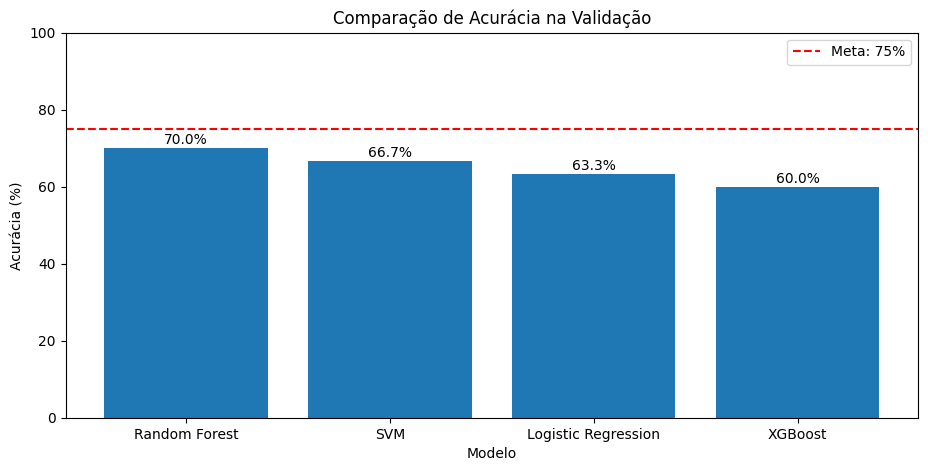

In [48]:
# GRÁFICO COMPARATIVO DE ACURÁCIA NA VALIDAÇÃO

# Ordena os resultados do melhor para o pior
plot_df = results_val_df.sort_values("Acurácia_Validação", ascending=False).copy()

# Cria o gráfico
fig, ax = plt.subplots(figsize=(11, 5))

bars = ax.bar(plot_df["Modelo"], plot_df["Acurácia_Validação"])

# Linha de referência da meta da atividade
ax.axhline(75, linestyle="--", color="red", label="Meta: 75%")

# Título e rótulos
ax.set_title("Comparação de Acurácia na Validação")
ax.set_ylabel("Acurácia (%)")
ax.set_xlabel("Modelo")
ax.set_ylim(0, 100)

# Valores acima das barras
for bar, value in zip(bars, plot_df["Acurácia_Validação"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

# Legenda
ax.legend()

# Exibe o gráfico
plt.show()

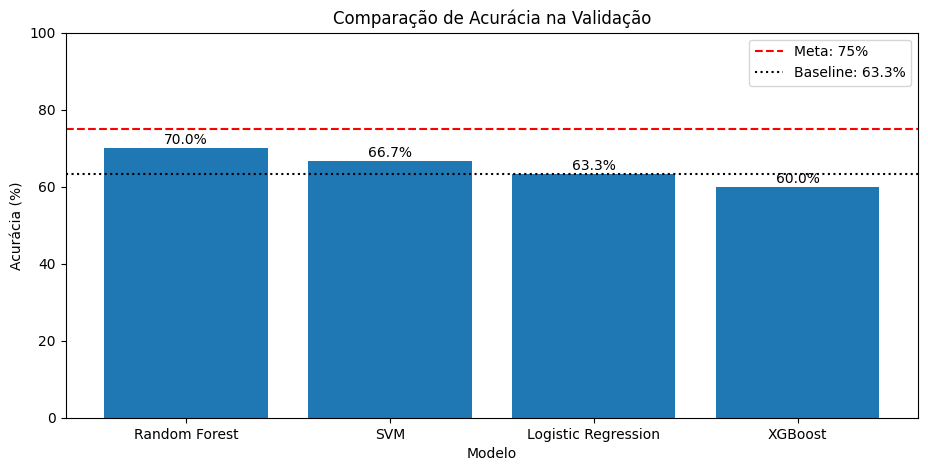

In [49]:
# =========================================================
# GRÁFICO COMPARATIVO DE ACURÁCIA NA VALIDAÇÃO
# =========================================================

plot_df = results_val_df.sort_values("Acurácia_Validação", ascending=False).copy()

fig, ax = plt.subplots(figsize=(11, 5))

bars = ax.bar(plot_df["Modelo"], plot_df["Acurácia_Validação"])

# Linha da meta da atividade
ax.axhline(75, linestyle="--", color="red", label="Meta: 75%")

# Linha do baseline
ax.axhline(baseline_acc_val * 100, linestyle=":", color="black", label=f"Baseline: {baseline_acc_val * 100:.1f}%")

ax.set_title("Comparação de Acurácia na Validação")
ax.set_ylabel("Acurácia (%)")
ax.set_xlabel("Modelo")
ax.set_ylim(0, 100)

for bar, value in zip(bars, plot_df["Acurácia_Validação"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

ax.legend()
plt.show()

Os hiperparâmetros apresentados abaixo foram definidos previamente com base em testes realizados no notebook, buscando um equilíbrio entre capacidade preditiva e controle de overfitting.

## 18. Seleção do melhor modelo com base na validação
Após comparar os modelos no conjunto de validação, selecionamos aquele que apresentou a maior acurácia nessa etapa.

In [53]:
# Seleciona o modelo com maior acurácia no conjunto de validação
best_result = max(results_val, key=lambda x: x["val_accuracy"])

# Armazena o nome do melhor modelo e o threshold correspondente
best_model_name = best_result["model_name"]
best_threshold = best_result["best_threshold"]
best_val_accuracy = best_result["val_accuracy"]

# Exibe o modelo vencedor da validação
print("Melhor modelo na validação:", best_model_name)
print("Melhor threshold na validação:", best_threshold)
print(f"Acurácia na validação: {best_val_accuracy * 100:.2f}%")

Melhor modelo na validação: Random Forest
Melhor threshold na validação: 0.4
Acurácia na validação: 70.00%


## 19. Reajuste do melhor modelo com treino + validação

Depois de selecionar o melhor modelo no conjunto de validação, realizamos um novo treinamento utilizando a junção de **treino + validação**.

Essa etapa permite que o modelo final seja ajustado com uma quantidade maior de dados antes da avaliação definitiva no conjunto de teste.

Em seguida:
- calculamos as probabilidades da classe positiva no teste
- aplicamos o threshold escolhido na validação
- medimos a acurácia final no conjunto de teste

Assim, mantemos o teste como etapa final e independente, utilizando-o apenas para avaliar o desempenho do modelo já selecionado.

In [56]:
# Reinstancia e reentreina o melhor modelo usando todo o conjunto disponível antes do teste (treino + validação)
if best_model_name == "Logistic Regression":
    final_model = LogisticRegression(
        C=0.5,
        class_weight="balanced",
        max_iter=2000,
        random_state=random_state
    )
    
    # Modelos sensíveis à escala utilizam os dados padronizados
    final_model.fit(X_train_full_scaled, y_train_full)
    proba_test = final_model.predict_proba(X_test_scaled)[:, 1]

elif best_model_name == "Random Forest":
    final_model = RandomForestClassifier(
        n_estimators=800,
        max_depth=8,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=random_state,
        n_jobs=-1
    )
    
    # Modelos baseados em árvores utilizam os dados originais
    final_model.fit(X_train_full, y_train_full)
    proba_test = final_model.predict_proba(X_test)[:, 1]

elif best_model_name == "SVM":
    final_model = SVC(
        kernel="rbf",
        C=5,
        gamma="scale",
        probability=True,
        class_weight="balanced",
        random_state=random_state
    )
    
    # SVM utiliza dados escalados
    final_model.fit(X_train_full_scaled, y_train_full)
    proba_test = final_model.predict_proba(X_test_scaled)[:, 1]

elif best_model_name == "XGBoost":
    final_model = XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        eval_metric="logloss",
        random_state=random_state
    )
    
    # XGBoost utiliza os dados originais
    final_model.fit(X_train_full, y_train_full)
    proba_test = final_model.predict_proba(X_test)[:, 1]

else:
    raise ValueError(f"Modelo não reconhecido: {best_model_name}")

# Aplica o threshold escolhido na validação para converter probabilidade em classe
pred_test = (proba_test >= best_threshold).astype(int)

# Calcula a acurácia final no conjunto de teste
test_acc = accuracy_score(y_test, pred_test)
test_hits = int((y_test == pred_test).sum())

print(f"Acurácia final no teste: {test_acc * 100:.2f}%")
print(f"Acertos: {test_hits}/{len(y_test)}")

Acurácia final no teste: 46.67%
Acertos: 14/30


## 20. Comparação com o baseline no teste final
Após avaliar o melhor modelo no conjunto de teste, comparamos seu desempenho com o baseline da classe majoritária.

Essa comparação é importante para verificar se o modelo final realmente agregou valor preditivo ou se um resultado semelhante poderia ser obtido com uma estratégia extremamente simples.

Ao organizar os dois resultados lado a lado, fica mais fácil interpretar o ganho efetivo do modelo selecionado.

In [57]:
# O baseline sempre prevê a classe majoritária observada no treino
baseline_pred_test = np.repeat(majority_class, len(y_test))

# Calcula a acurácia do baseline no teste
baseline_acc_test = accuracy_score(y_test, baseline_pred_test)

# Organiza a comparação entre baseline e melhor modelo em uma tabela
comparison = pd.DataFrame({
    "Modelo": ["Baseline (classe majoritária)", best_model_name],
    "Acurácia_Teste": [round(baseline_acc_test * 100, 2), round(test_acc * 100, 2)]
})

# Exibe a comparação final
comparison

,Modelo,Acurácia_Teste
0,Baseline (classe majoritária),46.67
1,Random Forest,46.67


Os resultados sugerem que o problema de prever a direção diária do IBOVESPA no curtíssimo prazo apresenta alta complexidade e baixa previsibilidade. Embora o Random Forest tenha sido o melhor modelo na validação, seu desempenho no teste final não superou o baseline, indicando limitação de generalização para dados futuros.

## 21. Classification report e matriz de confusão

Classification report no conjunto de teste:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        16
           1       0.47      1.00      0.64        14

    accuracy                           0.47        30
   macro avg       0.23      0.50      0.32        30
weighted avg       0.22      0.47      0.30        30



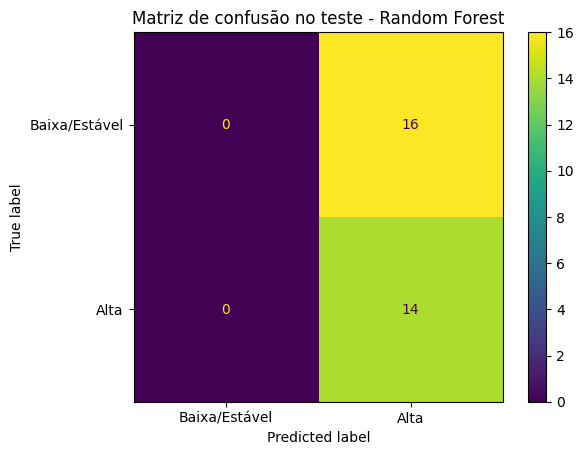

In [65]:
# Exibe métricas detalhadas de classificação no conjunto de teste
print("Classification report no conjunto de teste:")
print(classification_report(y_test, pred_test))

# Calcula a matriz de confusão
cm = confusion_matrix(y_test, pred_test)

# Plota a matriz de confusão com nomes mais intuitivos para as classes
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Baixa/Estável", "Alta"]
)
disp.plot(values_format="d")

# Define o título do gráfico
plt.title(f"Matriz de confusão no teste - {best_model_name}")

# Exibe o gráfico
plt.show()

## 22. Conferência das previsões finais dos últimos 30 dias

Para complementar a avaliação quantitativa, organizamos uma tabela com as previsões realizadas no conjunto de teste.

Nela, reunimos:
- o fechamento do dia atual
- o fechamento real do dia seguinte
- a classe real
- a probabilidade estimada de alta
- a classe prevista pelo modelo

Essa visualização permite inspecionar as previsões de forma individual, facilitando a interpretação dos acertos e erros do modelo no período final analisado.

In [73]:
# Monta uma tabela com os resultados do conjunto de teste
df_resultado = pd.DataFrame({
    "Close_hoje": df_model.loc[y_test.index, "Close"],
    "Close_amanha_real": df_model.loc[y_test.index, "Next_Close"],
    "y_real": y_test,
    "proba_alta": proba_test,
    "y_pred": pred_test
}, index=y_test.index)

# Arredonda a probabilidade para facilitar a leitura
df_resultado["proba_alta"] = df_resultado["proba_alta"].round(4)

# Adiciona colunas textuais para facilitar a interpretação
df_resultado["direcao_real"] = np.where(df_resultado["y_real"] == 1, "Alta", "Baixa/Estável")
df_resultado["direcao_prevista"] = np.where(df_resultado["y_pred"] == 1, "Alta", "Baixa/Estável")

# Indica se a previsão foi um acerto ou erro
df_resultado["resultado"] = np.where(
    df_resultado["y_real"] == df_resultado["y_pred"],
    "Acerto",
    "Erro"
)

# Exibe a tabela final de previsões
df_resultado

,Close_hoje,Close_amanha_real,y_real,proba_alta,y_pred,direcao_real,direcao_prevista,resultado
Date,,,,,,,,
2026-01-23,178859.0,178721.0,0,0.4949,1,Baixa/Estável,Alta,Erro
2026-01-26,178721.0,181919.0,1,0.5095,1,Alta,Alta,Acerto
2026-01-27,181919.0,184691.0,1,0.5530,1,Alta,Alta,Acerto
2026-01-28,184691.0,183134.0,0,0.5101,1,Baixa/Estável,Alta,Erro
2026-01-29,183134.0,181364.0,0,0.4904,1,Baixa/Estável,Alta,Erro
2026-01-30,181364.0,182793.0,1,0.4892,1,Alta,Alta,Acerto
2026-02-02,182793.0,185674.0,1,0.5010,1,Alta,Alta,Acerto
2026-02-03,185674.0,181708.0,0,0.4785,1,Baixa/Estável,Alta,Erro
2026-02-04,181708.0,182127.0,1,0.4948,1,Alta,Alta,Acerto


## 23. Importância das variáveis

Quando o modelo selecionado possui medida nativa de importância das variáveis, podemos analisar quais features tiveram maior peso na tomada de decisão.

No caso de modelos baseados em árvores, como **Random Forest** e **XGBoost**, essa análise ajuda a identificar quais atributos derivados do histórico do índice contribuíram mais para a previsão da direção do mercado.

A visualização abaixo apresenta as variáveis mais relevantes segundo o modelo final ajustado.

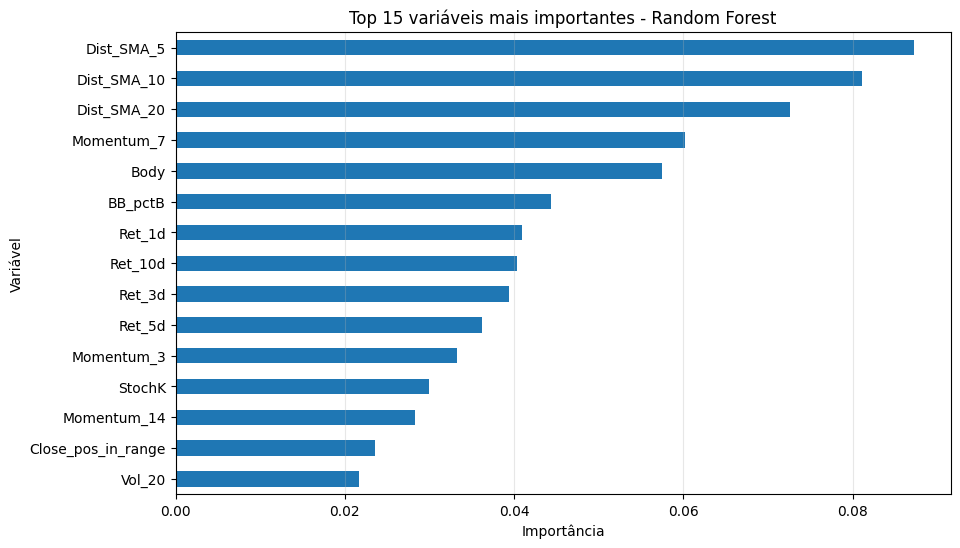

,Importância
Dist_SMA_5,0.087210
Dist_SMA_10,0.081082
Dist_SMA_20,0.072556
Momentum_7,0.060188
Body,0.057410
BB_pctB,0.044322
Ret_1d,0.040904
Ret_10d,0.040277
Ret_3d,0.039389
Ret_5d,0.036180


In [75]:
# Apenas modelos baseados em árvores possuem importância nativa das variáveis
if best_model_name in ["Random Forest", "XGBoost"]:
    
    # Calcula a importância de cada feature no modelo final
    importances = pd.Series(
        final_model.feature_importances_,
        index=X_train_full.columns
    ).sort_values(ascending=False).head(15)

    # Plota as 15 variáveis mais importantes
    fig, ax = plt.subplots(figsize=(10, 6))
    importances.sort_values().plot(kind="barh", ax=ax)

    # Personaliza o gráfico
    ax.set_title(f"Top 15 variáveis mais importantes - {best_model_name}")
    ax.set_xlabel("Importância")
    ax.set_ylabel("Variável")
    ax.grid(axis="x", alpha=0.3)

    plt.show()

    # Exibe a tabela com os valores de importância
    display(importances.to_frame("Importância"))

else:
    print("O modelo selecionado não possui feature_importances_ nativas.")

## 24. Conclusão técnica

### Escolha dos modelos
Foram testados modelos com perfis diferentes:
- **Logistic Regression** como baseline supervisionado e interpretável
- **Random Forest** e **XGBoost** para capturar não linearidades
- **SVM** como alternativa para fronteiras mais complexas

### Tratamento da natureza sequencial
A sequência temporal foi preservada em todo o fluxo:
- ordenação cronológica da série
- criação de lags, médias móveis, volatilidade e momentum
- separação temporal entre treino, validação e teste
- uso dos **últimos 30 dias** como teste final

### Trade-off entre acurácia e overfitting
Em séries financeiras diárias, acurácia muito alta pode indicar ajuste excessivo ao histórico.  
Por isso:
- o melhor modelo foi escolhido pela **validação**
- o **teste final** foi mantido isolado até o fim
- foi usado um **baseline** para comparação

### Observação importante
A meta de **75% de acurácia** é bastante agressiva para previsão direcional diária de mercado.  
Caso o resultado fique abaixo disso em algumas execuções ou períodos, isso deve ser discutido como limitação natural do problema, e não mascarado.